### 차트 작성 시 한글 깨짐 방지를 위한 koreanize-matplotlib 설치

In [2]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 40.8 MB/s eta 0:00:00


### 라이브러리 import

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

### 1. 데이터 로드 및 확인

In [4]:
pima_columns = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree_function', 'age', 'outcome']
pima_data_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
df = pd.read_csv(pima_data_url, names=pima_columns)

In [5]:
df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# 타겟 변수 확인 (outcome: 0=정상, 1=당뇨병)
print(df['outcome'].value_counts())

outcome
0    500
1    268
Name: count, dtype: int64


### 2. 데이터 전처리 및 분할

In [7]:
# Feature(X)와 Target(y) 분리
X = df.drop('outcome', axis=1)
y = df['outcome']

# 학습용/테스트용 데이터 분할 (8:2)
# stratify=y: 타겟 변수의 클래스 비율을 유지하며 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

학습 데이터: (614, 8)
테스트 데이터: (154, 8)


### 3. 모델 학습 및 예측

In [8]:
# max_iter=1000: 수렴을 위해 반복 횟수 충분히 설정
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 테스트 데이터 예측
y_pred = model.predict(X_test)

### 3. 혼동 행렬 (Confusion Matrix) 분석

In [9]:
# 혼동 행렬 계산
cm = confusion_matrix(y_test, y_pred)

# 혼동 행렬 값 추출 (TP, TN, FP, FN)
# sklearn의 confusion_matrix는 [[TN, FP], [FN, TP]] 순서로 반환함
tn, fp, fn, tp = cm.ravel()

print(f"True Negative (TN): {tn}")
print(f"False Positive (FP): {fp} (Type I Error)")
print(f"False Negative (FN): {fn} (Type II Error)")
print(f"True Positive (TP): {tp}")

True Negative (TN): 82
False Positive (FP): 18 (Type I Error)
False Negative (FN): 26 (Type II Error)
True Positive (TP): 28


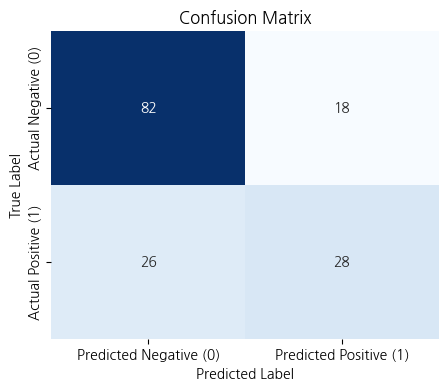

In [11]:
# 혼동 행렬 시각화
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 4. 핵심 성능 지표

In [14]:
# 정확도 (Accuracy): 전체 중 정확히 예측한 비율
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 (Accuracy) : {accuracy:.4f}")

# 정밀도 (Precision): TP / (TP + FP)
# 모델이 Positive라고 예측한 것 중 실제 Positive의 비율
precision = precision_score(y_test, y_pred)
print(f"정밀도 (Precision): {precision:.4f}")

# 재현율 (Recall): TP / (TP + FN)
# 실제 Positive인 것 중 모델이 정확히 예측한 비율
recall = recall_score(y_test, y_pred)
print(f"재현율 (Recall)   : {recall:.4f}")

# F1-Score: 정밀도와 재현율의 조화 평균
f1 = f1_score(y_test, y_pred)
print(f"F1-Score          : {f1:.4f}")

정확도 (Accuracy) : 0.7143
정밀도 (Precision): 0.6087
재현율 (Recall)   : 0.5185
F1-Score          : 0.5600
